# PIPELINE



# =========================================================
# 1. IMPORTS MÍNIMOS ESTABLES
# =========================================================
# Importación de librerías necesarias para:
# - Manipulación de datos
# - Visualización
# - Modelado predictivo
# - Evaluación de métricas
# Se fija semilla para garantizar reproducibilidad.


# =========================================================
# 2. CARGA Y MERGE
# =========================================================
# Carga del dataset de conectividad funcional (triángulo superior vectorizado).
# Carga de variables fenotípicas (diagnóstico, sexo).
# Unión por identificador único de sujeto.
# Validación de dimensiones y consistencia tras el merge.


# =========================================================
# 3. IDENTIFICACIÓN DE FEATURES Y TARGETS
# =========================================================
# Separación de:
# - Variables de conectividad (X)
# - Variable objetivo (diagnóstico TDAH)
# - Variable sexo para análisis estratificado


# =========================================================
# 3.1 ESTIMACIÓN DEL Nº DE ROIs
# =========================================================
# Inferencia del número aproximado de regiones cerebrales (ROIs)
# a partir del número de conexiones disponibles:
# p = N*(N-1)/2
# Verificación de coherencia estructural del conectoma.


# =========================================================
# 3.2 DISTRIBUCIÓN GLOBAL DE CONECTIVIDAD
# =========================================================
# Análisis descriptivo de la distribución de valores de conectividad.
# Evaluación de rango, media y dispersión.
# Evidencia de estructura y heterogeneidad en los datos.


# =========================================================
# 3.3 VARIANZA POR CONEXIÓN
# =========================================================
# Cálculo de la varianza de cada conexión entre sujetos.
# Identificación de enlaces con mayor variabilidad.
# Confirmación de que el conectoma no es homogéneo.


# =========================================================
# 3.4 DIFERENCIAS POR SEXO (SIN MODELADO)
# =========================================================
# Comparación descriptiva de conectividad media entre mujeres y varones.
# Exploración preliminar de posibles patrones diferenciales.
# No se aplica modelo predictivo en esta etapa.


# =========================================================
# 3.5 BALANCE DE CLASES
# =========================================================
# Evaluación de distribución de diagnóstico (TDAH vs Control).
# Identificación de posible desbalance.
# Análisis estratificado por sexo.


# =========================================================
# 4. PIPELINE DE MACHINE LEARNING
# =========================================================
# Definición del esquema general de modelado:
# - Estandarización
# - Reducción dimensional
# - Clasificación
# - Validación cruzada


# =========================================================
# 4.2 MODELO PCA + SVM (BASELINE)
# =========================================================
# Aplicación de PCA para reducir dimensionalidad y estabilizar el problema.
# Entrenamiento de un clasificador SVM como baseline.
# Objetivo: obtener una referencia inicial de desempeño.


# =========================================================
# 4.3 VALIDACIÓN CRUZADA OUT-OF-FOLD
# =========================================================
# Generación de predicciones fuera de muestra.
# Evaluación robusta sin leakage.
# Almacenamiento de predicciones para análisis posterior.


# =========================================================
# 4.4 MÉTRICAS POR SEXO (OOF)
# =========================================================
# Cálculo de métricas globales:
# - Accuracy
# - Balanced Accuracy
# - ROC-AUC
# Construcción de matriz de confusión.
# Evaluación estratificada por sexo para detectar posible degradación.


# =========================================================
# 4.5 VARIANZA EXPLICADA POR PCA
# =========================================================
# Cálculo de varianza explicada acumulada.
# Justificación del número de componentes seleccionados.
# Evitar que PCA funcione como "caja negra".


# =========================================================
# 4.6 SENSIBILIDAD AL UMBRAL EN MUJERES
# =========================================================
# Análisis exploratorio del efecto de modificar el umbral de decisión.
# Evaluación del trade-off sensibilidad/especificidad en mujeres.
# Identificación de posibles mejoras en detección femenina.

# =========================================================
# MODELO B — AGREGACIÓN POR REDES FUNCIONALES
# =========================================================
# Reducción estructural basada en organización neurofuncional
# (Schaefer Atlas → agregación red–red).
# Se pasa de ~19.900 conexiones a 136 features interpretables.


# =========================================================
# PASO 1 — CARGA DEL ATLAS SCHAEFER
# =========================================================
# Incorporación de la asignación ROI → red funcional.
# Permite mapear cada conexión a un par de redes.


# =========================================================
# PASO 2 — AGREGACIÓN RED–RED
# =========================================================
# Transformación del vector de conectividad individual
# en conectividad promedio entre redes funcionales.
# Obtención de matriz X_network (n_sujetos × 136).


# =========================================================
# PASO 3 — MODELO SIN PCA
# =========================================================
# Entrenamiento de modelo logístico directamente sobre
# features red–red (estructura biológicamente interpretable).
# Comparación con baseline PCA + SVM.


# =========================================================
# ANÁLISIS DE COEFICIENTES
# =========================================================
# Interpretación de pesos del modelo.
# Identificación de redes funcionales más relevantes.
# Discusión en términos neurobiológicos.


# =========================================================
# MODELO DIFERENCIADO POR SEXO
# =========================================================
# Entrenamiento y evaluación separados por sexo.
# Análisis comparativo de desempeño y patrones diferenciales.


In [1]:
#1 Imports mínimos estables

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, roc_auc_score)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC




In [2]:
#2 Carga y Merge

base_path = "TRAIN_NEW/"
id_col = "participant_id"

df_cat   = pd.read_excel(base_path + "TRAIN_CATEGORICAL_METADATA_new.xlsx")
df_quant = pd.read_excel(base_path + "TRAIN_QUANTITATIVE_METADATA_new.xlsx")
df_conn  = pd.read_csv(base_path + "TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")
df_sol   = pd.read_excel(base_path + "TRAINING_SOLUTIONS.xlsx")

df_all = (
    df_cat.merge(df_quant, on=id_col, how="inner")
          .merge(df_conn,  on=id_col, how="inner")
          .merge(df_sol,   on=id_col, how="inner")
)

print("Merged shape:", df_all.shape)


Merged shape: (1213, 19930)


In [3]:
#3 Identificar columnas y targets
target_col = "ADHD_Outcome"
sex_col = "Sex_F"

conn_cols = [c for c in df_conn.columns if c != id_col]
cat_cols = df_cat.columns.drop(id_col).tolist()
num_cols_meta = df_quant.columns.drop(id_col).tolist()
num_cols = num_cols_meta + conn_cols

X = df_all.drop(columns=[id_col, target_col, sex_col])
y = df_all[target_col].astype(int)
sex = df_all[sex_col].astype(int)

print("Connectome features:", len(conn_cols))
print("Categorical:", len(cat_cols), "Quant meta:", len(num_cols_meta))


Connectome features: 19900
Categorical: 9 Quant meta: 18


In [4]:
#3.1 Estimar nº ROIs a partir de columnas (~19900)
n_edges = len(conn_cols)
n_rois = int((1 + math.sqrt(1 + 8*n_edges)) / 2)
print("Estimated ROIs:", n_rois, "| Expected edges:", n_rois*(n_rois-1)//2)

#escribir en tesis:“Las matrices originales son NxN (N≈200) y simétricas”“El dataset incluye solo el triángulo superior vectorizado (N(N−1)/2)”


Estimated ROIs: 200 | Expected edges: 19900


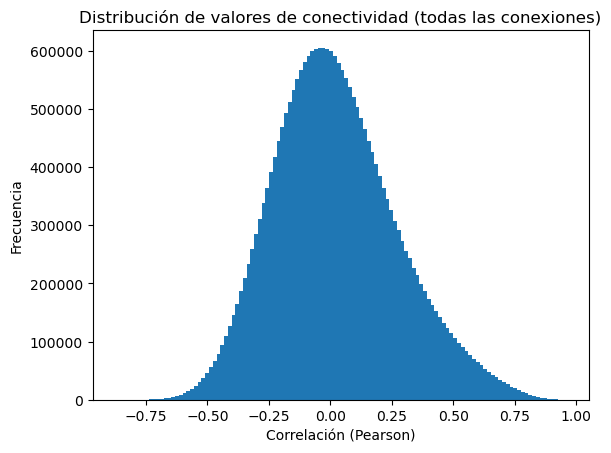

In [5]:
#3.2 Distribución global de conectividad

vals = df_all[conn_cols].to_numpy().ravel()
vals = vals[np.isfinite(vals)]
plt.figure()
plt.hist(vals, bins=120)
plt.title("Distribución de valores de conectividad (todas las conexiones)")
plt.xlabel("Correlación (Pearson)")
plt.ylabel("Frecuencia")
plt.show()


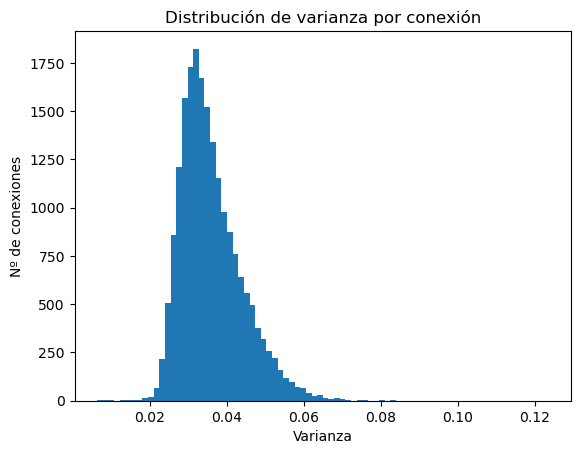

In [6]:
#3.3 Varianza por conexión (heterogeneidad)

edge_var = df_all[conn_cols].var()
plt.figure()
plt.hist(edge_var, bins=80)
plt.title("Distribución de varianza por conexión")
plt.xlabel("Varianza")
plt.ylabel("Nº de conexiones")
plt.show()


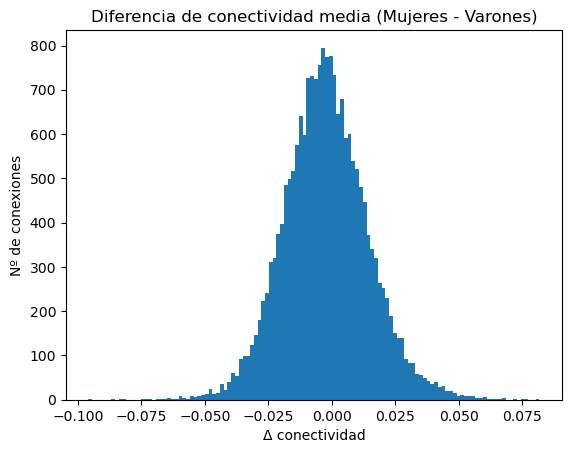

In [7]:
#3.4 Diferencias por sexo (sin modelo)

mean_f = df_all.loc[sex==1, conn_cols].mean()
mean_m = df_all.loc[sex==0, conn_cols].mean()
diff = (mean_f - mean_m).to_numpy()

plt.figure()
plt.hist(diff, bins=120)
plt.title("Diferencia de conectividad media (Mujeres - Varones)")
plt.xlabel("Δ conectividad")
plt.ylabel("Nº de conexiones")
plt.show()


In [8]:
#3.5 Balance de clases

print("ADHD class balance:")
print(y.value_counts(normalize=True).rename("proportion"))

print("\nSex balance:")
print(sex.value_counts(normalize=True).rename("proportion"))

print("\nContingencia Sex x ADHD:")
print(pd.crosstab(sex, y, normalize="index"))


ADHD class balance:
ADHD_Outcome
1    0.685078
0    0.314922
Name: proportion, dtype: float64

Sex balance:
Sex_F
0    0.657049
1    0.342951
Name: proportion, dtype: float64

Contingencia Sex x ADHD:
ADHD_Outcome         0         1
Sex_F                           
0             0.271016  0.728984
1             0.399038  0.600962


In [9]:
#4 Pipeline de ML 
#4.1 Preprocesamiento 

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)


In [10]:
#4.2 Modelo PCA + SVM baseline

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("pca", PCA(n_components=300, random_state=42)),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
])


In [11]:
#4.3 Evaluación con CV (predicciones out-of-fold)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# predicciones out-of-fold (sin leakage)
y_prob_oof = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:,1]
y_pred_oof = (y_prob_oof >= 0.5).astype(int)

print("=== Resultados globales (OOF CV) ===")
print(classification_report(y, y_pred_oof))
print("Balanced Acc:", balanced_accuracy_score(y, y_pred_oof))
print("ROC AUC:", roc_auc_score(y, y_prob_oof))
print("Confusion matrix:\n", confusion_matrix(y, y_pred_oof))


=== Resultados globales (OOF CV) ===
              precision    recall  f1-score   support

           0       0.45      0.03      0.05       382
           1       0.69      0.99      0.81       831

    accuracy                           0.68      1213
   macro avg       0.57      0.51      0.43      1213
weighted avg       0.61      0.68      0.57      1213

Balanced Acc: 0.5058687886291039
ROC AUC: 0.5651489090920547
Confusion matrix:
 [[ 10 372]
 [ 12 819]]


In [12]:
#4.4 Métricas por sexo (OOF)
for g, name in [(1,"Mujeres"), (0,"Varones")]:
    idx = (sex==g)
    print(f"\n=== {name} (OOF CV) ===")
    print(classification_report(y[idx], y_pred_oof[idx]))
    print("Balanced Acc:", balanced_accuracy_score(y[idx], y_pred_oof[idx]))
    print("Confusion matrix:\n", confusion_matrix(y[idx], y_pred_oof[idx]))




=== Mujeres (OOF CV) ===
              precision    recall  f1-score   support

           0       0.45      0.03      0.06       166
           1       0.60      0.98      0.75       250

    accuracy                           0.60       416
   macro avg       0.53      0.50      0.40       416
weighted avg       0.54      0.60      0.47       416

Balanced Acc: 0.5030602409638554
Confusion matrix:
 [[  5 161]
 [  6 244]]

=== Varones (OOF CV) ===
              precision    recall  f1-score   support

           0       0.45      0.02      0.04       216
           1       0.73      0.99      0.84       581

    accuracy                           0.73       797
   macro avg       0.59      0.51      0.44       797
weighted avg       0.66      0.73      0.63       797

Balanced Acc: 0.5064105628864666
Confusion matrix:
 [[  5 211]
 [  6 575]]


In [13]:
#4.5 Varianza explicada por PCA (interpretación)

clf.fit(X, y)  # fit completo solo para inspección

pca_step = clf.named_steps["pca"]
print("Varianza explicada acumulada (300 comps):",
      pca_step.explained_variance_ratio_.sum())


Varianza explicada acumulada (300 comps): 0.6948280270081397


In [14]:
#4.6 Sensibilidad al umbral en mujeres

from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 17)
rows = []

for thr in thresholds:
    pred = (y_prob_oof >= thr).astype(int)
    idx_f = (sex==1)

    f1_f = f1_score(y[idx_f], pred[idx_f])
    bal_f = balanced_accuracy_score(y[idx_f], pred[idx_f])

    rows.append((thr, f1_f, bal_f))

df_thr = pd.DataFrame(rows, columns=["thr", "F1_female", "BalAcc_female"])

print(df_thr.sort_values("F1_female", ascending=False).head(5))


    thr  F1_female  BalAcc_female
0  0.10   0.750751            0.5
1  0.15   0.750751            0.5
2  0.20   0.750751            0.5
3  0.25   0.750751            0.5
4  0.30   0.750751            0.5


## MODELO B

# PASO 1 — Necesitamos el atlas Schaefer

In [17]:
# ===============================
# Cargar Atlas Schaefer 200 / 17 networks
# ===============================

atlas = pd.read_csv("Schaefer200_merged_labels(Schaefer200_merged_labels).csv")

print(atlas.head())
print("Total ROIs en atlas:", atlas.shape[0])


   ROI Label                         ROI Name   R   A   S  \
0          1    17Networks_LH_VisCent_ExStr_1 -26 -78 -14   
1          2    17Networks_LH_VisCent_ExStr_2 -26 -96 -12   
2          3  17Networks_LH_VisCent_Striate_1  -6 -92  -4   
3          4    17Networks_LH_VisCent_ExStr_3 -22 -96   6   
4          5    17Networks_LH_VisCent_ExStr_4 -40 -84  10   

                      Label Name      Network Name  Full Component Name  
0    17Networks_LH_VisCent_ExStr    central visual  extrastriate cortex  
1    17Networks_LH_VisCent_ExStr    central visual  extrastriate cortex  
2  17Networks_LH_VisCent_Striate  central visual         striate cortex  
3    17Networks_LH_VisCent_ExStr    central visual  extrastriate cortex  
4    17Networks_LH_VisCent_ExStr    central visual  extrastriate cortex  
Total ROIs en atlas: 200


In [18]:
df_conn.columns[:15]

Index(['participant_id', '0throw_1thcolumn', '0throw_2thcolumn',
       '0throw_3thcolumn', '0throw_4thcolumn', '0throw_5thcolumn',
       '0throw_6thcolumn', '0throw_7thcolumn', '0throw_8thcolumn',
       '0throw_9thcolumn', '0throw_10thcolumn', '0throw_11thcolumn',
       '0throw_12thcolumn', '0throw_13thcolumn', '0throw_14thcolumn'],
      dtype='object')

# PASO 2 — Código para agregación por redes

In [19]:
# ===============================
# 5. Network-level aggregation (Schaefer200 / 17 networks)
# ===============================

atlas_path = "Schaefer200_merged_labels(Schaefer200_merged_labels).csv"
atlas = pd.read_csv(atlas_path)

# sanity checks
print("Atlas shape:", atlas.shape)
print(atlas.columns)

# ROI Label debe ser 1..200
atlas = atlas.sort_values("ROI Label")
assert atlas["ROI Label"].min() == 1 and atlas["ROI Label"].max() == 200, "ROI labels no son 1..200"

# Usamos Network Name (en tu screenshot: 'central visual', 'peripheral visual', etc.)
# OJO: puede haber nombres repetidos o con espacios; los normalizamos
labels = atlas["Network Name"].astype(str).str.strip().tolist()
networks = sorted(pd.Series(labels).unique())

print("Nº networks detectadas:", len(networks))
print("Networks:", networks)

# ROI indices (0..199) por red
net_idx = {net: [i for i, lab in enumerate(labels) if lab == net] for net in networks}

# índices del triángulo superior para reconstruir NxN
n_rois = 200
upper = np.triu_indices(n_rois, k=1)

# triángulo superior para vectorizar red-red
u_net = np.triu_indices(len(networks), k=1)
print("Features red-red esperadas:", len(u_net[0]))  # debería ser 136 si son 17 redes


Atlas shape: (200, 8)
Index(['ROI Label', 'ROI Name', 'R', 'A', 'S', 'Label Name', 'Network Name',
       'Full Component Name'],
      dtype='object')
Nº networks detectadas: 17
Networks: ['central visual', 'control A', 'control B', 'control C', 'default A', 'default B', 'default C', 'dorsal attention A', 'dorsal attention B', 'limbic A', 'limbic B', 'peripheral visual', 'salience / ventral attention A', 'salience / ventral attention B', 'somatomotor A', 'somatomotor B', 'temporal parietal']
Features red-red esperadas: 136


In [20]:
#5.2 Función: vector (19.900) → features red–red (136)

def edges_to_network_features(edge_vector):
    """
    edge_vector: array shape (19900,), triángulo superior en orden estándar.
    Devuelve: array shape (n_net*(n_net-1)/2,)
    """
    mat = np.zeros((n_rois, n_rois), dtype=np.float32)
    mat[upper] = edge_vector
    mat = mat + mat.T  # simetría
    # (opcional) diagonal a 1, pero no afecta medias entre redes
    np.fill_diagonal(mat, 1.0)

    n_net = len(networks)
    net_mat = np.zeros((n_net, n_net), dtype=np.float32)

    for i, net_i in enumerate(networks):
        idx_i = net_idx[net_i]
        for j, net_j in enumerate(networks):
            idx_j = net_idx[net_j]
            sub = mat[np.ix_(idx_i, idx_j)]
            net_mat[i, j] = sub.mean()

    return net_mat[u_net]


In [21]:
#5.3 Construir la matriz X_network (1213 × 136)

# df_all ya lo tenés mergeado y conn_cols ya definidos
X_edges = df_all[conn_cols].to_numpy(dtype=np.float32)

X_net = np.vstack([edges_to_network_features(v) for v in X_edges])
print("X_net shape:", X_net.shape)

# dataframe con nombres legibles (netA_netB)
net_pair_names = []
for i in range(len(networks)):
    for j in range(i+1, len(networks)):
        net_pair_names.append(f"{networks[i]}__{networks[j]}")

X_net_df = pd.DataFrame(X_net, columns=net_pair_names)

# metadata (num + cat) de tu df_all
meta_df = df_all[num_cols_meta + cat_cols].copy()

# Dataset final: red-red + metadata
X_struct = pd.concat([X_net_df.reset_index(drop=True), meta_df.reset_index(drop=True)], axis=1)

y = df_all[target_col].astype(int).to_numpy()
sex = df_all[sex_col].astype(int).to_numpy()

print("X_struct shape:", X_struct.shape)


X_net shape: (1213, 136)
X_struct shape: (1213, 163)


#  PASO 3 — Nuevo modelo sin PCA

In [22]:
#6.1 Preprocesamiento metadata + modelo (Logistic)

from sklearn.linear_model import LogisticRegression

# identificar columnas categóricas y numéricas dentro de X_struct
cat_cols2 = cat_cols  # mismas categóricas
num_cols2 = [c for c in X_struct.columns if c not in cat_cols2]  # todo lo demás (incluye net features)

preproc2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num_cols2),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols2),
    ]
)

clf2 = Pipeline(steps=[
    ("prep", preproc2),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_prob_oof = cross_val_predict(clf2, X_struct, y, cv=cv, method="predict_proba")[:, 1]
y_pred_oof = (y_prob_oof >= 0.5).astype(int)

print("=== Network-aggregated + metadata (LogReg) OOF ===")
print(classification_report(y, y_pred_oof))
print("Balanced Acc:", balanced_accuracy_score(y, y_pred_oof))
print("ROC AUC:", roc_auc_score(y, y_prob_oof))
print("Confusion:\n", confusion_matrix(y, y_pred_oof))

for g, name in [(1, "Mujeres"), (0, "Varones")]:
    idx = (sex == g)
    print(f"\n=== {name} (OOF) ===")
    print(classification_report(y[idx], y_pred_oof[idx]))
    print("Balanced Acc:", balanced_accuracy_score(y[idx], y_pred_oof[idx]))
    print("Confusion:\n", confusion_matrix(y[idx], y_pred_oof[idx]))


=== Network-aggregated + metadata (LogReg) OOF ===
              precision    recall  f1-score   support

           0       0.55      0.66      0.60       382
           1       0.83      0.75      0.79       831

    accuracy                           0.72      1213
   macro avg       0.69      0.70      0.69      1213
weighted avg       0.74      0.72      0.73      1213

Balanced Acc: 0.7046925107578708
ROC AUC: 0.7906861725921586
Confusion:
 [[252 130]
 [208 623]]

=== Mujeres (OOF) ===
              precision    recall  f1-score   support

           0       0.63      0.72      0.67       166
           1       0.79      0.72      0.75       250

    accuracy                           0.72       416
   macro avg       0.71      0.72      0.71       416
weighted avg       0.73      0.72      0.72       416

Balanced Acc: 0.716433734939759
Confusion:
 [[119  47]
 [ 71 179]]

=== Varones (OOF) ===
              precision    recall  f1-score   support

           0       0.49      0.

# Analisis de Coeficientes

In [23]:
# ===============================
# 6.2 Interpretación del modelo estructural
# ===============================

# Reentrenamos en todo el dataset SOLO para interpretar coeficientes
clf2.fit(X_struct, y)

feature_names = clf2.named_steps["prep"].get_feature_names_out()
coefs = clf2.named_steps["lr"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
})

coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df.head(15)


,feature,coef,abs_coef
149,num__SDQ_SDQ_Hyperactivity,1.104528,1.104528
155,cat__Basic_Demos_Enroll_Year_2016.0,-1.043702,1.043702
71,num__default B__dorsal attention A,0.927903,0.927903
182,cat__Barratt_Barratt_P1_Edu_3.0,0.899120,0.899120
42,num__control B__somatomotor A,0.807758,0.807758
167,cat__PreInt_Demos_Fam_Child_Ethnicity_3.0,0.735443,0.735443
60,num__default A__dorsal attention A,-0.732775,0.732775
176,cat__PreInt_Demos_Fam_Child_Race_10.0,-0.704553,0.704553
61,num__default A__dorsal attention B,0.680020,0.680020
191,cat__Barratt_Barratt_P1_Occ_10.0,0.661195,0.661195


# Modelo diferenciado por sexo
# Entrenamos:
# Modelo SOLO mujeres
# Modelo SOLO varones
# Se compara coeficientes red–red. Respuesta a pregunta de investigación.


# PASO 1 - SEPARAR DATASETS 

In [24]:
# ===============================
# 7. Modelos separados por sexo
# ===============================

# Mujeres
X_f = X_struct[sex == 1]
y_f = y[sex == 1]

# Varones
X_m = X_struct[sex == 0]
y_m = y[sex == 0]

print("Mujeres:", X_f.shape)
print("Varones:", X_m.shape)


Mujeres: (416, 163)
Varones: (797, 163)


#  PASO 2 — Definir modelo estructural (misma estructura que 6.1)

In [25]:
#Reutilizamos preproc2, pero definimos un pipeline nuevo para claridad:

from sklearn.linear_model import LogisticRegression

clf_sex = Pipeline(steps=[
    ("prep", preproc2),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear"
    ))
])


#  PASO 3 — Evaluación CV mujeres

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Mujeres
y_prob_f = cross_val_predict(clf_sex, X_f, y_f, cv=cv, method="predict_proba")[:,1]
y_pred_f = (y_prob_f >= 0.5).astype(int)

print("=== MODELO SOLO MUJERES ===")
print(classification_report(y_f, y_pred_f))
print("Balanced Acc:", balanced_accuracy_score(y_f, y_pred_f))
print("Confusion:\n", confusion_matrix(y_f, y_pred_f))


=== MODELO SOLO MUJERES ===
              precision    recall  f1-score   support

           0       0.62      0.66      0.64       166
           1       0.77      0.74      0.75       250

    accuracy                           0.71       416
   macro avg       0.70      0.70      0.70       416
weighted avg       0.71      0.71      0.71       416

Balanced Acc: 0.6993253012048193
Confusion:
 [[110  56]
 [ 66 184]]


#  PASO 4 — Evaluación CV varones

In [27]:
# Varones
y_prob_m = cross_val_predict(clf_sex, X_m, y_m, cv=cv, method="predict_proba")[:,1]
y_pred_m = (y_prob_m >= 0.5).astype(int)

print("=== MODELO SOLO VARONES ===")
print(classification_report(y_m, y_pred_m))
print("Balanced Acc:", balanced_accuracy_score(y_m, y_pred_m))
print("Confusion:\n", confusion_matrix(y_m, y_pred_m))


=== MODELO SOLO VARONES ===
              precision    recall  f1-score   support

           0       0.47      0.60      0.53       216
           1       0.83      0.74      0.79       581

    accuracy                           0.71       797
   macro avg       0.65      0.67      0.66       797
weighted avg       0.73      0.71      0.72       797

Balanced Acc: 0.6726987314336712
Confusion:
 [[130  86]
 [149 432]]


#  PASO 5 — Extraer coeficientes por sexo

In [28]:
# Mujeres
clf_sex.fit(X_f, y_f)
feat_names = clf_sex.named_steps["prep"].get_feature_names_out()
coef_f = clf_sex.named_steps["lr"].coef_[0]

coef_df_f = pd.DataFrame({
    "feature": feat_names,
    "coef_female": coef_f,
    "abs_coef_female": np.abs(coef_f)
}).sort_values("abs_coef_female", ascending=False)

print("Top 10 Mujeres:")
display(coef_df_f.head(10))


# Varones
clf_sex.fit(X_m, y_m)
coef_m = clf_sex.named_steps["lr"].coef_[0]

coef_df_m = pd.DataFrame({
    "feature": feat_names,
    "coef_male": coef_m,
    "abs_coef_male": np.abs(coef_m)
}).sort_values("abs_coef_male", ascending=False)

print("Top 10 Varones:")
display(coef_df_m.head(10))


Top 10 Mujeres:


,feature,coef_female,abs_coef_female
149,num__SDQ_SDQ_Hyperactivity,1.737167,1.737167
128,num__salience / ventral attention A__somatomot...,-1.544802,1.544802
194,cat__Barratt_Barratt_P1_Occ_25.0,-1.473859,1.473859
24,num__control A__limbic B,1.241791,1.241791
71,num__default B__dorsal attention A,1.104320,1.104320
43,num__control B__somatomotor B,-1.075800,1.075800
103,num__dorsal attention B__salience / ventral at...,-0.995919,0.995919
109,num__limbic A__peripheral visual,-0.975189,0.975189
208,cat__Barratt_Barratt_P2_Occ_10.0,-0.966688,0.966688
155,cat__Basic_Demos_Enroll_Year_2016.0,-0.951838,0.951838


Top 10 Varones:


,feature,coef_male,abs_coef_male
60,num__default A__dorsal attention A,-1.356400,1.356400
193,cat__Barratt_Barratt_P1_Occ_20.0,-1.215485,1.215485
149,num__SDQ_SDQ_Hyperactivity,1.187225,1.187225
155,cat__Basic_Demos_Enroll_Year_2016.0,-0.966230,0.966230
157,cat__Basic_Demos_Enroll_Year_2018.0,0.955047,0.955047
43,num__control B__somatomotor B,0.898335,0.898335
180,cat__MRI_Track_Scan_Location_3.0,0.869888,0.869888
119,num__limbic B__somatomotor B,-0.836365,0.836365
174,cat__PreInt_Demos_Fam_Child_Race_8.0,-0.819989,0.819989
196,cat__Barratt_Barratt_P1_Occ_35.0,0.819885,0.819885


#  PASO 6 — Comparación directa redes red–red

In [29]:
# ===============================
# Comparación directa coeficientes por sexo
#¿Existen marcadores específicos del TDAH femenino?
# ===============================

# Filtrar solo features red-red (empiezan con num__ y contienen "__")
def is_network_feature(name):
    return name.startswith("num__") and "__" in name and "SDQ" not in name

net_features = [f for f in feat_names if is_network_feature(f)]

print("Total network features:", len(net_features))


Total network features: 145


#  PASO 7 — Construir dataframe comparativo

In [30]:
# Crear dataframes alineados
coef_f_df = pd.DataFrame({
    "feature": feat_names,
    "coef_female": coef_df_f.set_index("feature").reindex(feat_names)["coef_female"].values
})

coef_m_df = pd.DataFrame({
    "feature": feat_names,
    "coef_male": coef_df_m.set_index("feature").reindex(feat_names)["coef_male"].values
})

# Merge
coef_compare = coef_f_df.merge(coef_m_df, on="feature")

# Filtrar solo red-red
coef_compare = coef_compare[coef_compare["feature"].isin(net_features)].copy()

# Diferencias
coef_compare["diff_female_minus_male"] = coef_compare["coef_female"] - coef_compare["coef_male"]
coef_compare["abs_diff"] = np.abs(coef_compare["diff_female_minus_male"])

# Ordenar por mayor diferencia
coef_compare_sorted = coef_compare.sort_values("abs_diff", ascending=False)

display(coef_compare_sorted.head(15))


,feature,coef_female,coef_male,diff_female_minus_male,abs_diff
43,num__control B__somatomotor B,-1.075800,0.898335,-1.974135,1.974135
134,num__somatomotor A__temporal parietal,0.610166,-0.689739,1.299904,1.299904
24,num__control A__limbic B,1.241791,-0.029995,1.271786,1.271786
49,num__control C__dorsal attention B,0.688597,-0.532677,1.221275,1.221275
60,num__default A__dorsal attention A,-0.146534,-1.356400,1.209867,1.209867
128,num__salience / ventral attention A__somatomot...,-1.544802,-0.391268,-1.153534,1.153534
105,num__dorsal attention B__somatomotor A,0.738759,-0.328473,1.067232,1.067232
90,num__default C__temporal parietal,0.648438,-0.414439,1.062877,1.062877
33,num__control B__default B,0.803544,-0.248404,1.051948,1.051948
119,num__limbic B__somatomotor B,0.143293,-0.836365,0.979658,0.979658


#  PASO 8 — Detectar conexiones con signo invertido


## Contar cuántas conexiones tienen signo invertido

In [32]:
# ===============================
# Cuántas conexiones tienen signo invertido
# ===============================

total_net_features = 136  # 17 redes → 136 pares únicos

n_sign_flip = coef_compare["sign_flip"].sum()

print("Total conexiones red–red:", total_net_features)
print("Con signo invertido:", n_sign_flip)
print("Proporción:", round(n_sign_flip / total_net_features, 3))



Total conexiones red–red: 136
Con signo invertido: 79
Proporción: 0.581


## Filtrar solo conexiones red–red (excluir metadata)

In [35]:
# Filtrar SOLO conexiones red-red
net_only = coef_compare[
    coef_compare["feature"].str.count("__") == 2
].copy()

print("N conexiones red-red reales:", net_only.shape[0])

N conexiones red-red reales: 136


## Ver qué redes aparecen más en inversiones

In [36]:
# ===============================
# Redes más involucradas en inversiones
# ===============================

# Extraer nombres red-red
net_only = net_only[net_only["sign_flip"] == True]

net_pairs = net_only["feature"].str.replace("num__", "")

# Separar redes
pairs_split = net_pairs.str.split("__", expand=True)
pairs_split.columns = ["net_1", "net_2"]

all_nets = pd.concat([pairs_split["net_1"], pairs_split["net_2"]])

print(all_nets.value_counts().head(10))


control A             12
default C             11
temporal parietal     10
somatomotor A         10
somatomotor B          9
peripheral visual      9
limbic B               9
central visual         9
dorsal attention A     9
dorsal attention B     9
Name: count, dtype: int64


## Visualización simple (opcional pero potente)

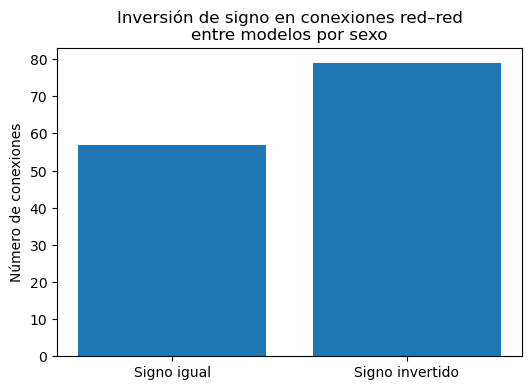

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(["Signo igual", "Signo invertido"],
        [136-79, 79])
plt.title("Inversión de signo en conexiones red–red\nentre modelos por sexo")
plt.ylabel("Número de conexiones")
plt.show()


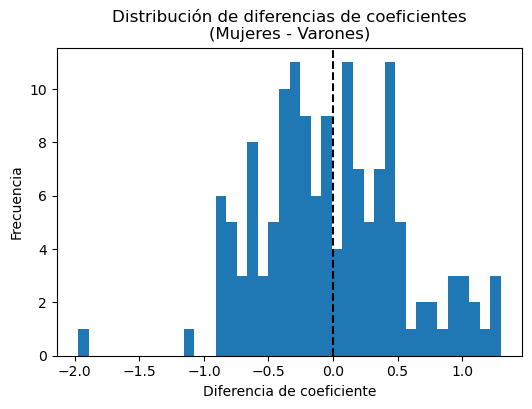

In [38]:
plt.figure(figsize=(6,4))
plt.hist(coef_compare["diff_female_minus_male"], bins=40)
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribución de diferencias de coeficientes\n(Mujeres - Varones)")
plt.xlabel("Diferencia de coeficiente")
plt.ylabel("Frecuencia")
plt.show()


## Heatmap

In [39]:
# Obtener nombres de redes únicos
net_names = sorted(set(
    [f.split("__")[1] for f in net_only["feature"]] +
    [f.split("__")[2] for f in net_only["feature"]]
))

print("N redes:", len(net_names))
print(net_names)


N redes: 17
['central visual', 'control A', 'control B', 'control C', 'default A', 'default B', 'default C', 'dorsal attention A', 'dorsal attention B', 'limbic A', 'limbic B', 'peripheral visual', 'salience / ventral attention A', 'salience / ventral attention B', 'somatomotor A', 'somatomotor B', 'temporal parietal']


In [40]:

matrix_diff = pd.DataFrame(
    np.zeros((17,17)),
    index=net_names,
    columns=net_names
)


In [41]:
for _, row in net_only.iterrows():
    feat = row["feature"].replace("num__", "")
    net1, net2 = feat.split("__")
    diff = row["diff_female_minus_male"]
    
    matrix_diff.loc[net1, net2] = diff
    matrix_diff.loc[net2, net1] = diff  # simétrica


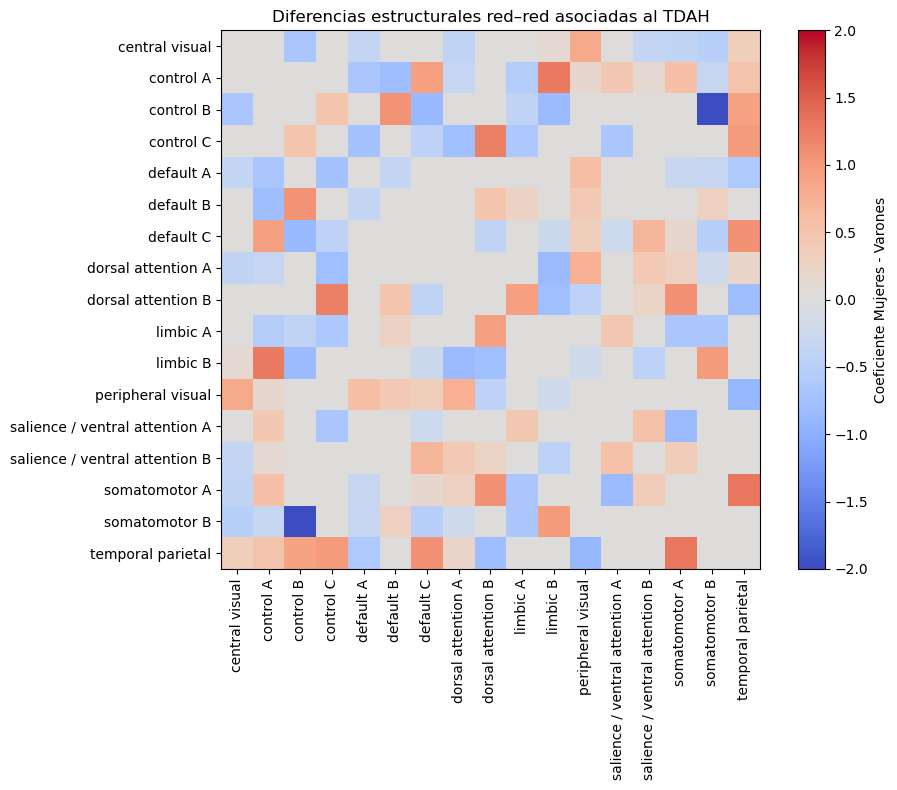

In [42]:

plt.figure(figsize=(10,8))
plt.imshow(matrix_diff, cmap="coolwarm", vmin=-2, vmax=2)
plt.colorbar(label="Coeficiente Mujeres - Varones")
plt.xticks(range(17), net_names, rotation=90)
plt.yticks(range(17), net_names)
plt.title("Diferencias estructurales red–red asociadas al TDAH")
plt.tight_layout()
plt.show()

In [43]:
top_diff = net_only.sort_values("abs_diff", ascending=False).head(15)
display(top_diff[["feature", "coef_female", "coef_male",
                  "diff_female_minus_male"]])

,feature,coef_female,coef_male,diff_female_minus_male
43,num__control B__somatomotor B,-1.075800,0.898335,-1.974135
134,num__somatomotor A__temporal parietal,0.610166,-0.689739,1.299904
24,num__control A__limbic B,1.241791,-0.029995,1.271786
49,num__control C__dorsal attention B,0.688597,-0.532677,1.221275
105,num__dorsal attention B__somatomotor A,0.738759,-0.328473,1.067232
90,num__default C__temporal parietal,0.648438,-0.414439,1.062877
33,num__control B__default B,0.803544,-0.248404,1.051948
119,num__limbic B__somatomotor B,0.143293,-0.836365,0.979658
57,num__control C__temporal parietal,0.521552,-0.451616,0.973168
100,num__dorsal attention B__limbic A,0.930446,-0.005894,0.936339


## Bootstrap de estabilidad

In [ ]:
# ==========================================
# Bootstrap estabilidad coeficientes con features fijas
# (evita que OneHot cambie columnas en cada resample)
# ==========================================

from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression

# 1) Fit del preprocesador UNA vez sobre todo el dataset
preproc2.fit(X_struct)

# 2) Transformación fija
X_fixed = preproc2.transform(X_struct)

# 3) Nombres de features fijos (del preprocesador)
feat_names_fixed = preproc2.get_feature_names_out()

# 4) Modelo LR (mismo que venías usando)
lr = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")

# 5) Bootstrap
n_boot = 200  # si querés subir a 500 después
coef_matrix = np.zeros((n_boot, X_fixed.shape[1]))

for i in range(n_boot):
    idx = resample(np.arange(X_fixed.shape[0]), replace=True, random_state=42+i)
    X_res = X_fixed[idx]
    y_res = y[idx]

    lr.fit(X_res, y_res)
    coef_matrix[i, :] = lr.coef_[0]

# 6) Estadísticos de estabilidad
coef_mean = coef_matrix.mean(axis=0)
coef_std  = coef_matrix.std(axis=0)

coef_stability = pd.DataFrame({
    "feature": feat_names_fixed,
    "coef_mean": coef_mean,
    "coef_std": coef_std,
    "stability_ratio": np.abs(coef_mean) / (coef_std + 1e-6)
})

# Filtrar solo conexiones red-red reales (num__red__red)
net_only_features = [
    f for f in feat_names_fixed
    if f.startswith("num__") and f.count("__") == 2
]

coef_stability_net = (
    coef_stability[coef_stability["feature"].isin(net_only_features)]
    .sort_values("stability_ratio", ascending=False)
)

print("N features total:", len(feat_names_fixed))
print("N red-red reales:", coef_stability_net.shape[0])

display(coef_stability_net.head(15))



## intervalo de confianza 95% por coeficiente

In [ ]:
# IC 95% bootstrap
low = np.percentile(coef_matrix, 2.5, axis=0)
high = np.percentile(coef_matrix, 97.5, axis=0)

coef_stability["ci_low"] = low
coef_stability["ci_high"] = high

coef_stability_net_ci = coef_stability[
    coef_stability["feature"].isin(net_only_features)
].copy()

coef_stability_net_ci["ci_crosses_0"] = (
    (coef_stability_net_ci["ci_low"] <= 0) & (coef_stability_net_ci["ci_high"] >= 0)
)

# Top 15 más estables y que NO cruzan 0
top_stable = coef_stability_net_ci.sort_values("stability_ratio", ascending=False)
display(top_stable.head(15))


## Mejora de sensibilidad diagnostica femenina ajustando el criterio de decisón 

In [ ]:
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, recall_score

thresholds = np.linspace(0.2, 0.8, 25)

results_thr = []

for thr in thresholds:
    
    y_pred_thr = (y_prob_f >= thr).astype(int)
    
    bal_acc = balanced_accuracy_score(y_f, y_pred_thr)
    recall_adhd = recall_score(y_f, y_pred_thr, pos_label=1)
    recall_noadhd = recall_score(y_f, y_pred_thr, pos_label=0)
    
    results_thr.append({
        "threshold": thr,
        "balanced_accuracy": bal_acc,
        "recall_TDAH": recall_adhd,
        "recall_no_TDAH": recall_noadhd
    })

thr_df = pd.DataFrame(results_thr)

thr_df.sort_values("balanced_accuracy", ascending=False).head(10)


In [ ]:


plt.figure(figsize=(8,5))
plt.plot(thr_df["threshold"], thr_df["balanced_accuracy"], label="Balanced Acc")
plt.plot(thr_df["threshold"], thr_df["recall_TDAH"], label="Recall TDAH")
plt.plot(thr_df["threshold"], thr_df["recall_no_TDAH"], label="Recall No-TDAH")

plt.axvline(0.5, linestyle="--", color="gray", label="Umbral 0.5")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Efecto del umbral en modelo femenino")
plt.legend()
plt.show()


# Anexos

## Apartado 5 Resultados y Analisis 

In [ ]:
# ===============================
# TABLA 1 – Distribución de muestra
# ===============================

tabla1 = pd.DataFrame({
    "ADHD_proportion": y.value_counts(normalize=True),
    "Sex_proportion": sex.value_counts(normalize=True)
})

display(tabla1)

# Tabla contingencia
tabla1_cont = pd.crosstab(sex, y, normalize="index")
display(tabla1_cont)


In [ ]:
#Tabla 2 — Métricas globales Modelo A

from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score, confusion_matrix

print(classification_report(y, y_pred_oof))
print("Balanced Acc:", balanced_accuracy_score(y, y_pred_oof))
print("ROC AUC:", roc_auc_score(y, y_prob_oof))
print("Confusion:\n", confusion_matrix(y, y_pred_oof))


In [ ]:
#📊 Tabla 3 — Métricas estratificadas por sexo (Modelo A)

for g, name in [(1,"Mujeres"), (0,"Varones")]:
    idx = (sex==g)
    print(f"\n=== {name} ===")
    print(classification_report(y[idx], y_pred_oof[idx]))
    print("Balanced Acc:", balanced_accuracy_score(y[idx], y_pred_oof[idx]))


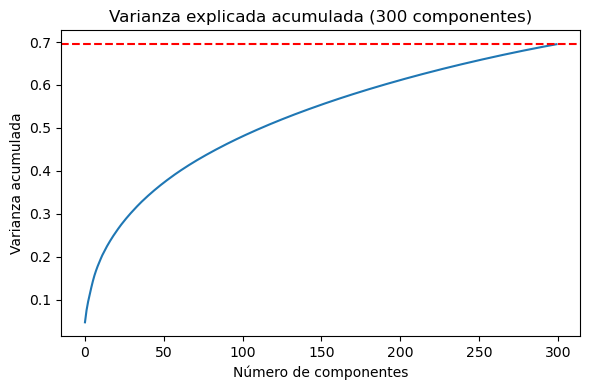

In [ ]:
# Figura 2 — Varianza explicada acumulada PCA

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca_step.explained_variance_ratio_))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza explicada acumulada (300 componentes)")
plt.axhline(0.6948, linestyle="--", color="red")
plt.tight_layout()
plt.show()


In [ ]:
#TABLA 4 — Top 10 conexiones red–red globales (RECOMENDADA)

top_global = coef_df[
    coef_df["feature"].str.count("__") == 2
].head(10)

top_global


In [ ]:
#TABLA 5 — Top 10 conexiones red–red por sexo

# ===============================
# TABLA 5 – Top 10 conexiones red–red por sexo
# ===============================

#  Filtrar SOLO conexiones red-red reales
def is_red_red(feature_name):
    return feature_name.startswith("num__") and feature_name.count("__") == 2

# Mujeres
top_female = coef_df_f[
    coef_df_f["feature"].apply(is_red_red)
].sort_values("abs_coef_female", ascending=False).head(10)

# Varones
top_male = coef_df_m[
    coef_df_m["feature"].apply(is_red_red)
].sort_values("abs_coef_male", ascending=False).head(10)

# 2️Limpiar nombres (quitar prefijo num__)
top_female = top_female.copy()
top_male = top_male.copy()

top_female["feature"] = top_female["feature"].str.replace("num__", "")
top_male["feature"] = top_male["feature"].str.replace("num__", "")

# 3Seleccionar columnas finales
top_female = top_female[["feature", "coef_female"]]
top_male = top_male[["feature", "coef_male"]]

# 4️Reset index
top_female = top_female.reset_index(drop=True)
top_male = top_male.reset_index(drop=True)

# 5️Mostrar resultados
print("=== TOP 10 CONEXIONES RED–RED – MUJERES ===")
display(top_female)

print("\n=== TOP 10 CONEXIONES RED–RED – VARONES ===")
display(top_male)


In [ ]:
# Unir ambas tablas por ranking
tabla5 = pd.concat(
    [
        top_female.rename(columns={"feature": "Feature_Female", 
                                   "coef_female": "Coef_Female"}),
        top_male.rename(columns={"feature": "Feature_Male", 
                                 "coef_male": "Coef_Male"})
    ],
    axis=1
)

display(tabla5)
